In [14]:
pip install ucimlrepo

In [15]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# metadata
print(auto_mpg.metadata)

# variable information
print(auto_mpg.variables)


{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

2.1 Exploratory Data Analysis

First rows of the dataset:
   displacement  cylinders  horsepower  weight  acceleration  model_year  \
0         307.0          8       130.0    3504          12.0          70   
1         350.0          8       165.0    3693          11.5          70   
2         318.0          8       150.0    3436          11.0          70   
3         304.0          8       150.0    3433          12.0          70   
4         302.0          8       140.0    3449          10.5          70   

   origin   mpg  
0       1  18.0  
1       1  15.0  
2       1  18.0  
3       1  16.0  
4       1  17.0  

Missing values per column:
displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64


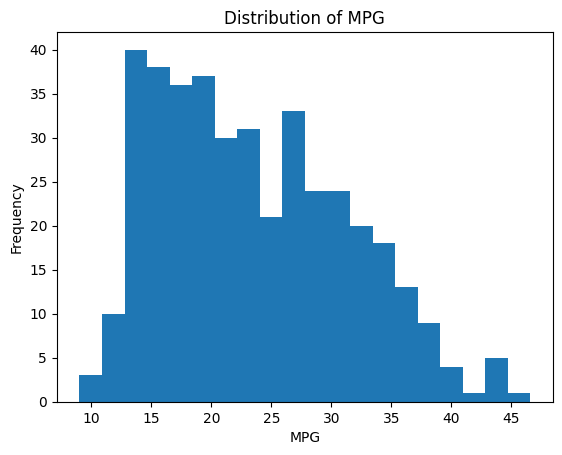

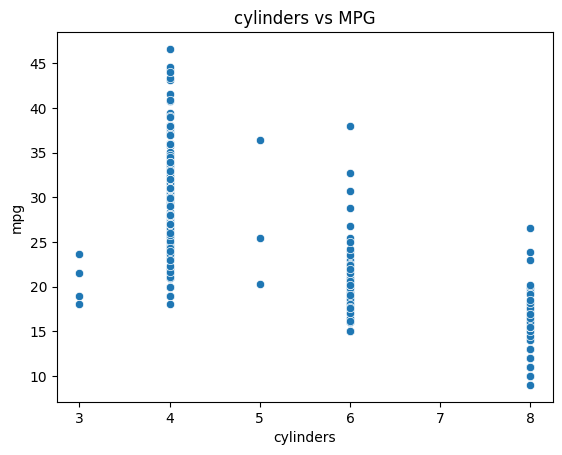

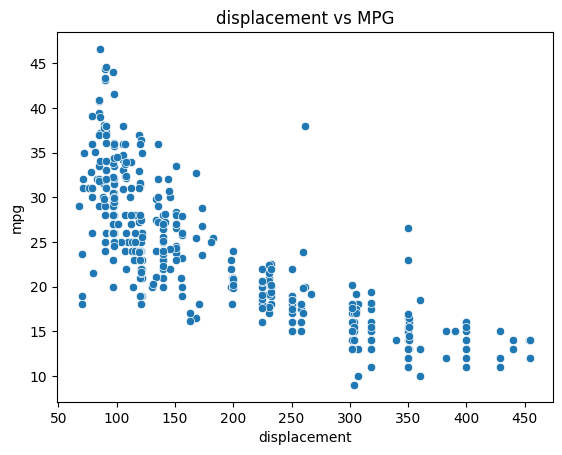

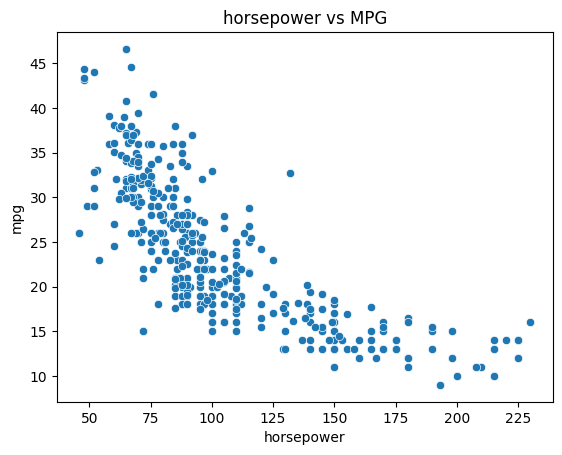

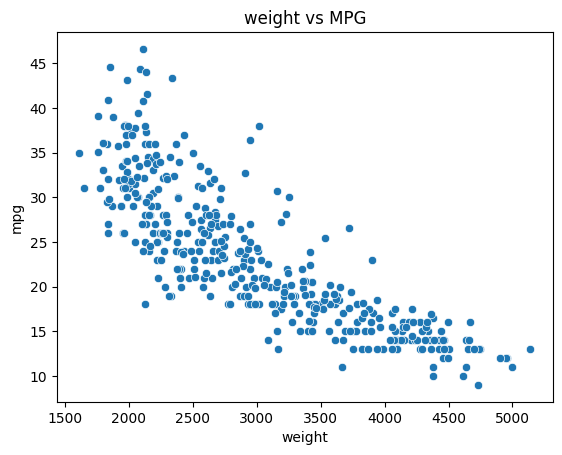

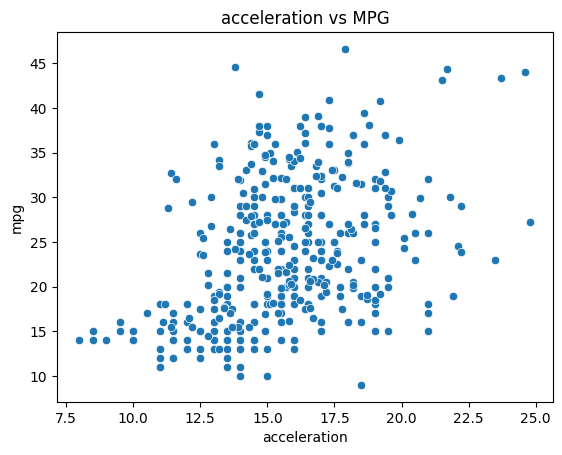

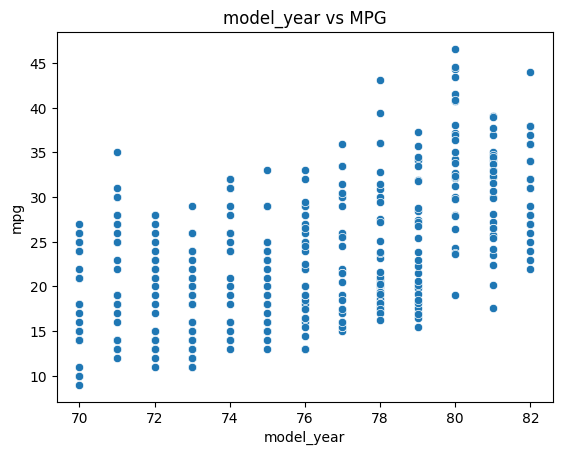

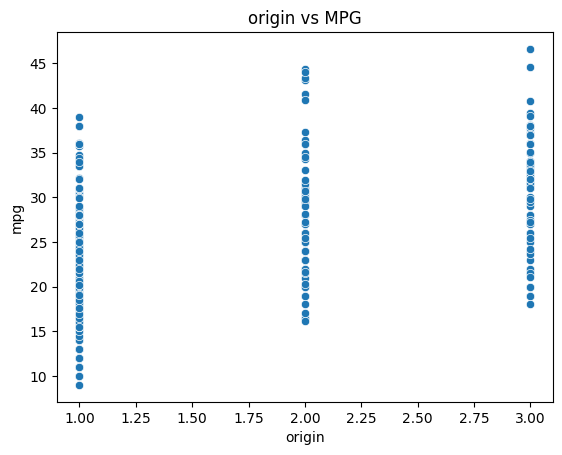

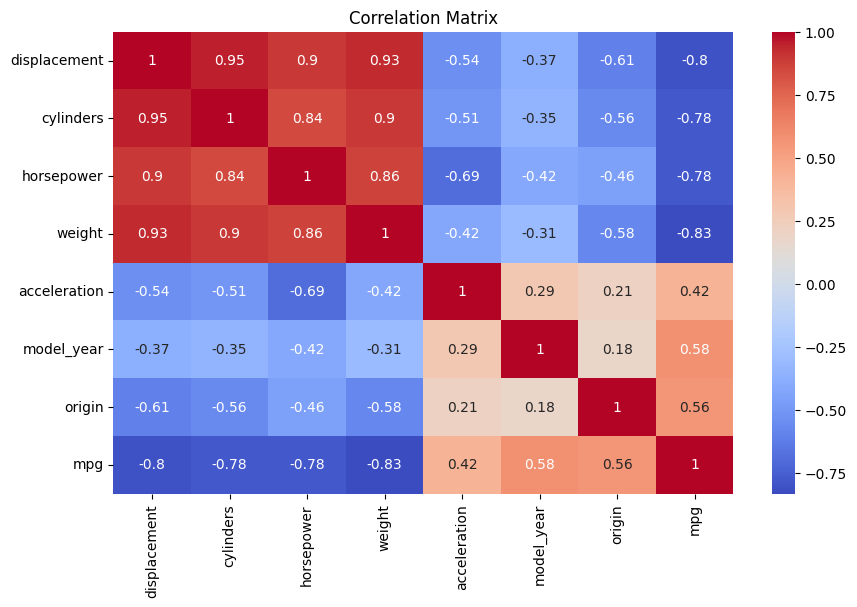

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# -----------------------------
# Load dataset
# -----------------------------
auto_mpg = fetch_ucirepo(id=9)

X = auto_mpg.data.features
y = auto_mpg.data.targets

df = pd.concat([X, y], axis=1)

# convert horsepower to numeric (important for this dataset)
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

print("First rows of the dataset:")
print(df.head())

# -----------------------------
# Missing values
# -----------------------------
print("\nMissing values per column:")
print(df.isnull().sum())

# -----------------------------
# Target distribution
# -----------------------------
plt.figure()
plt.hist(df['mpg'], bins=20)
plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# Relationship between features and mpg
# -----------------------------
features = ['cylinders','displacement','horsepower','weight','acceleration','model_year','origin']

for f in features:
    plt.figure()
    sns.scatterplot(x=df[f], y=df['mpg'])
    plt.title(f"{f} vs MPG")
    plt.show()

# -----------------------------
# Correlation matrix
# -----------------------------
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

2.2 Dataset and Preprocessing


In [17]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Load dataset
# -----------------------------
auto_mpg = fetch_ucirepo(id=9)

X = auto_mpg.data.features
y = auto_mpg.data.targets

df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
print(df.head())

# -----------------------------
# Convert horsepower to numeric
# -----------------------------
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# -----------------------------
# Handle missing values
# -----------------------------
print("\nMissing values before:")
print(df.isnull().sum())

df['horsepower'].fillna(df['horsepower'].median(), inplace=True)

print("\nMissing values after:")
print(df.isnull().sum())

# -----------------------------
# Define features and target
# -----------------------------
features = ['cylinders','displacement','horsepower','weight','acceleration','model_year','origin']

X = df[features]
y = df['mpg']

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Standardization
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTraining set size:", X_train.shape)
print("Test set size:", X_test.shape)

Dataset shape: (398, 8)
   displacement  cylinders  horsepower  weight  acceleration  model_year  \
0         307.0          8       130.0    3504          12.0          70   
1         350.0          8       165.0    3693          11.5          70   
2         318.0          8       150.0    3436          11.0          70   
3         304.0          8       150.0    3433          12.0          70   
4         302.0          8       140.0    3449          10.5          70   

   origin   mpg  
0       1  18.0  
1       1  15.0  
2       1  18.0  
3       1  16.0  
4       1  17.0  

Missing values before:
displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

Missing values after:
displacement    0
cylinders       0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

Training set size: (318, 7)
Test set size: (80, 7

/tmp/ipykernel_2787/3517193045.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].median(), inplace=True)


2.3 Linear Regression Baseline


MSE: 8.19774688582497
RMSE: 2.8631707748272666
MAE: 2.255363261283564
R2: 0.8475304239212405


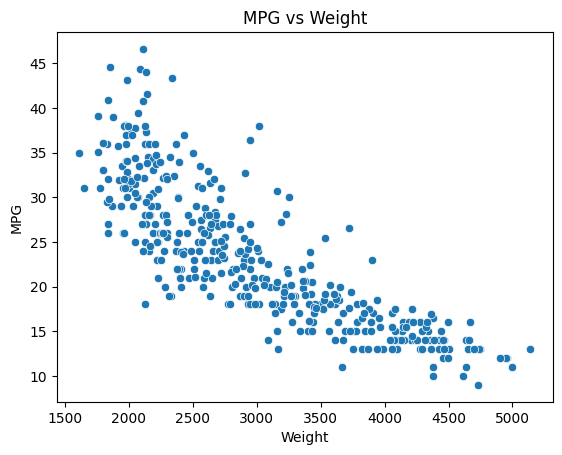

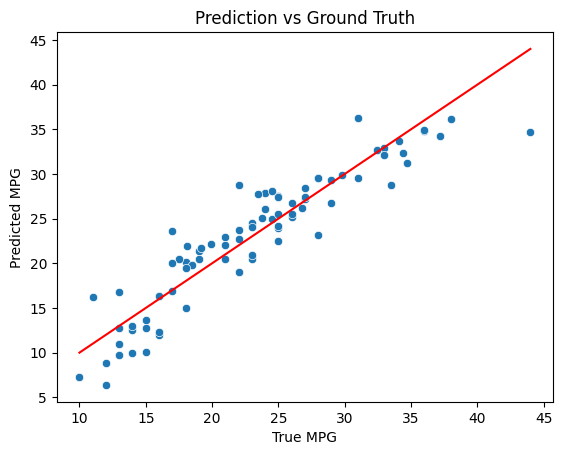

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Train Linear Regression
# -----------------------------
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# predictions
y_pred = model.predict(X_test_scaled)

# -----------------------------
# Evaluation metrics
# -----------------------------
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

# -----------------------------
# Feature-target relationship example
# -----------------------------
plt.figure()
sns.scatterplot(x=df["weight"], y=df["mpg"])
plt.title("MPG vs Weight")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

# -----------------------------
# Prediction vs Ground Truth
# -----------------------------
plt.figure()
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title("Prediction vs Ground Truth")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

2.4 Polynomial Regression and Model Complexity

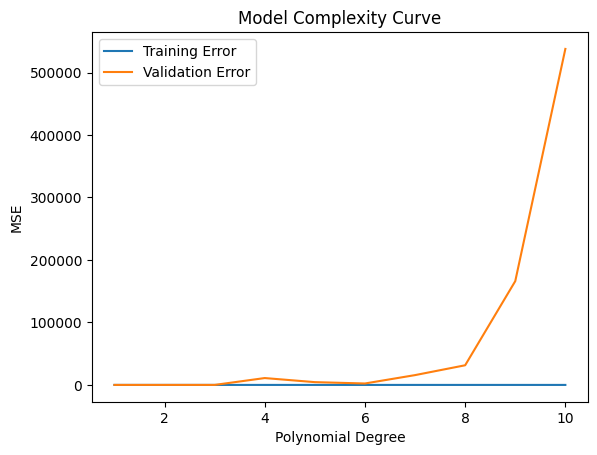

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

degrees = range(1, 11)

train_errors = []
val_errors = []

for d in degrees:

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("linear", LinearRegression())
    ])

    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_test_scaled)

    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_test, y_val_pred)

    train_errors.append(train_mse)
    val_errors.append(val_mse)

# Plot complexity curve
plt.figure()
plt.plot(degrees, train_errors, label="Training Error")
plt.plot(degrees, val_errors, label="Validation Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Model Complexity Curve")
plt.legend()
plt.show()

2.5 K-Nearest Neighbors (KNN) Regression

Best k: 2


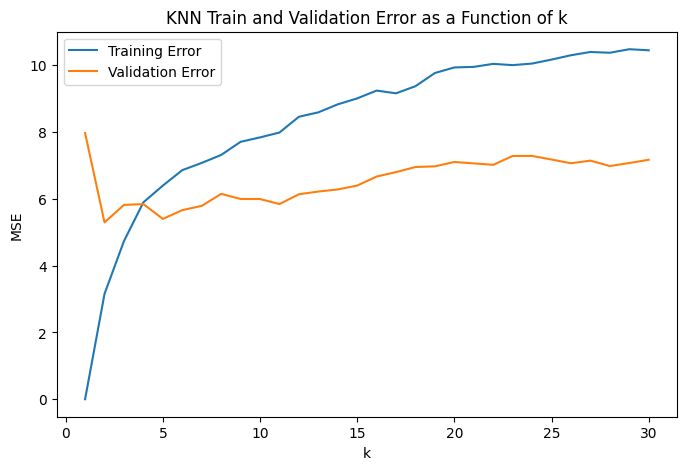

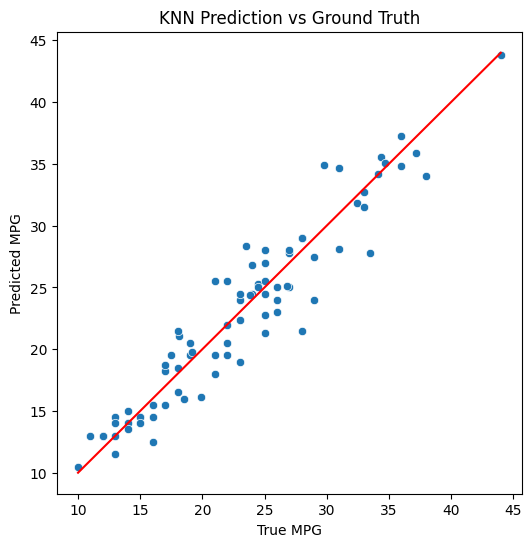

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# try multiple k values
k_values = range(1, 31)

train_errors = []
val_errors = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_test_scaled)

    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_test, y_val_pred)

    train_errors.append(train_mse)
    val_errors.append(val_mse)

# choose best k
best_k = k_values[np.argmin(val_errors)]
print("Best k:", best_k)

# train final KNN model
knn_model = KNeighborsRegressor(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

# predictions on test set
y_pred_knn = knn_model.predict(X_test_scaled)

# plot train and validation error as a function of k
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_errors, label="Training Error")
plt.plot(k_values, val_errors, label="Validation Error")
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("KNN Train and Validation Error as a Function of k")
plt.legend()
plt.show()

# plot prediction vs ground truth
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_knn)
plt.xlabel("True MPG")
plt.ylabel("Predicted MPG")
plt.title("KNN Prediction vs Ground Truth")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()

2.6 Optimization Behavior



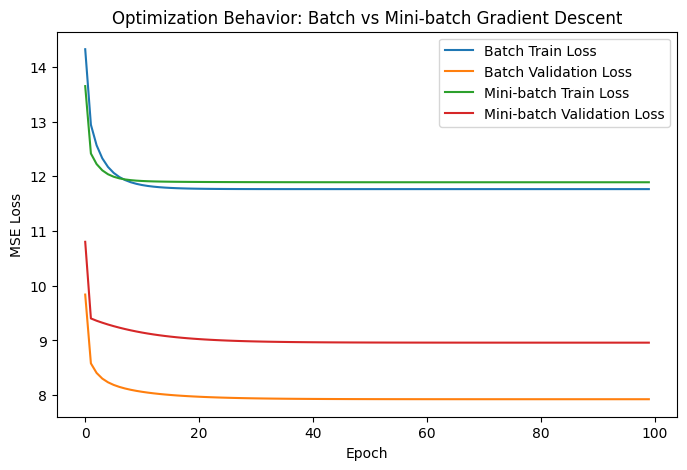

In [21]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

epochs = 100

# Batch Gradient Descent (batch size = full dataset)
batch_model = SGDRegressor(max_iter=1, learning_rate='constant', eta0=0.01, random_state=42)

batch_train_loss = []
batch_val_loss = []

for epoch in range(epochs):
    batch_model.partial_fit(X_train_scaled, y_train)

    train_pred = batch_model.predict(X_train_scaled)
    val_pred = batch_model.predict(X_test_scaled)

    batch_train_loss.append(mean_squared_error(y_train, train_pred))
    batch_val_loss.append(mean_squared_error(y_test, val_pred))


# Mini-batch Gradient Descent
mini_model = SGDRegressor(max_iter=1, learning_rate='constant', eta0=0.01, random_state=42)

mini_train_loss = []
mini_val_loss = []

batch_size = 32

for epoch in range(epochs):

    for i in range(0, len(X_train_scaled), batch_size):
        X_batch = X_train_scaled[i:i+batch_size]
        y_batch = y_train.iloc[i:i+batch_size]

        mini_model.partial_fit(X_batch, y_batch)

    train_pred = mini_model.predict(X_train_scaled)
    val_pred = mini_model.predict(X_test_scaled)

    mini_train_loss.append(mean_squared_error(y_train, train_pred))
    mini_val_loss.append(mean_squared_error(y_test, val_pred))


# Plot loss vs epochs
plt.figure(figsize=(8,5))

plt.plot(batch_train_loss, label="Batch Train Loss")
plt.plot(batch_val_loss, label="Batch Validation Loss")

plt.plot(mini_train_loss, label="Mini-batch Train Loss")
plt.plot(mini_val_loss, label="Mini-batch Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Optimization Behavior: Batch vs Mini-batch Gradient Descent")

plt.legend()
plt.show()

2.7 Model Comparison and Discussion- Detailed explanations and discussion for this section are provided in the accompanying Overleaf report.

3 Classification task: Classical Classification on CIFAR-10

In [23]:
from google.colab import files
uploaded = files.upload()

Saving cifar-10-python.tar.gz to cifar-10-python.tar.gz


In [24]:
!tar -xzf cifar-10-python.tar.gz

In [25]:
import os
print(os.listdir())
print(os.listdir("cifar-10-batches-py"))

['.config', 'cifar-10-python.tar.gz', 'cifar-10-batches-py', 'sample_data']
['test_batch', 'batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_5', 'readme.html', 'data_batch_3', 'data_batch_4']


In [26]:
import pickle
import numpy as np

def unpickle(file):
    with open(file, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d

data_dir = "cifar-10-batches-py"

X_train = []
y_train = []

for i in range(1,6):
    batch = unpickle(f"{data_dir}/data_batch_{i}")
    X_train.append(batch[b'data'])
    y_train.extend(batch[b'labels'])

X_train = np.concatenate(X_train)
y_train = np.array(y_train)

test_batch = unpickle(f"{data_dir}/test_batch")

X_test = test_batch[b'data']
y_test = np.array(test_batch[b'labels'])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (50000, 3072)
Test shape: (10000, 3072)


3.1 Baseline Models

In [27]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# very small subset for quick baseline
subset = 1000
X_small = X_train[:subset] / 255.0
y_small = y_train[:subset]

# train / validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42, stratify=y_small
)

print("Train split:", X_tr.shape)
print("Validation split:", X_val.shape)

# 1) Logistic Regression
log_reg = LogisticRegression(max_iter=100, random_state=42)
log_reg.fit(X_tr, y_tr)
y_pred_log = log_reg.predict(X_val)
log_acc = accuracy_score(y_val, y_pred_log)

# 2) Linear SVM
svm_model = LinearSVC(max_iter=1000, random_state=42)
svm_model.fit(X_tr, y_tr)
y_pred_svm = svm_model.predict(X_val)
svm_acc = accuracy_score(y_val, y_pred_svm)

# 3) KNN
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_tr, y_tr)
y_pred_knn = knn_model.predict(X_val)
knn_acc = accuracy_score(y_val, y_pred_knn)

print("\nValidation accuracies:")
print(f"Logistic Regression: {log_acc:.4f}")
print(f"Linear SVM:          {svm_acc:.4f}")
print(f"KNN:                 {knn_acc:.4f}")

Train split: (800, 3072)
Validation split: (200, 3072)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Validation accuracies:
Logistic Regression: 0.2900
Linear SVM:          0.2700
KNN:                 0.2750


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


3.2 Hyperparameter Selection


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

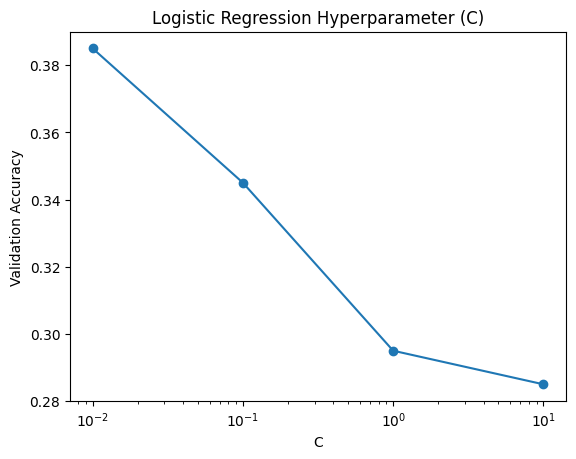

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


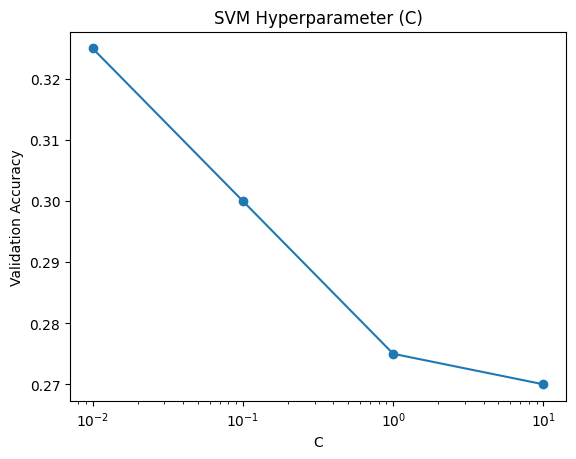

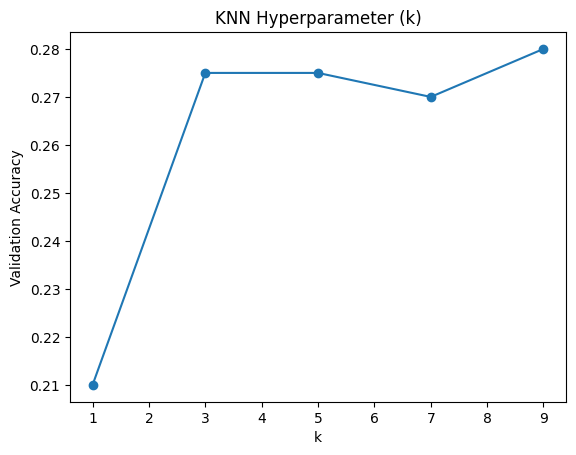

Logistic scores: [0.385, 0.345, 0.295, 0.285]
SVM scores: [0.325, 0.3, 0.275, 0.27]
KNN scores: [0.21, 0.275, 0.275, 0.27, 0.28]


In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

# --------------------------------
# Logistic Regression: tuning C
# --------------------------------
C_values = [0.01, 0.1, 1, 10]
log_scores = []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=200)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    log_scores.append(accuracy_score(y_val, pred))

plt.plot(C_values, log_scores, marker='o')
plt.xscale("log")
plt.title("Logistic Regression Hyperparameter (C)")
plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.show()

# --------------------------------
# SVM: tuning C
# --------------------------------
svm_scores = []

for C in C_values:
    model = LinearSVC(C=C, max_iter=2000)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    svm_scores.append(accuracy_score(y_val, pred))

plt.plot(C_values, svm_scores, marker='o')
plt.xscale("log")
plt.title("SVM Hyperparameter (C)")
plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.show()

# --------------------------------
# KNN: tuning k
# --------------------------------
k_values = [1,3,5,7,9]
knn_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    knn_scores.append(accuracy_score(y_val, pred))

plt.plot(k_values, knn_scores, marker='o')
plt.title("KNN Hyperparameter (k)")
plt.xlabel("k")
plt.ylabel("Validation Accuracy")
plt.show()

print("Logistic scores:", log_scores)
print("SVM scores:", svm_scores)
print("KNN scores:", knn_scores)

3.3 Evaluation and Analysis


Validation Accuracy
Logistic Regression: 0.29
Linear SVM: 0.27
KNN: 0.275


<Figure size 640x480 with 0 Axes>

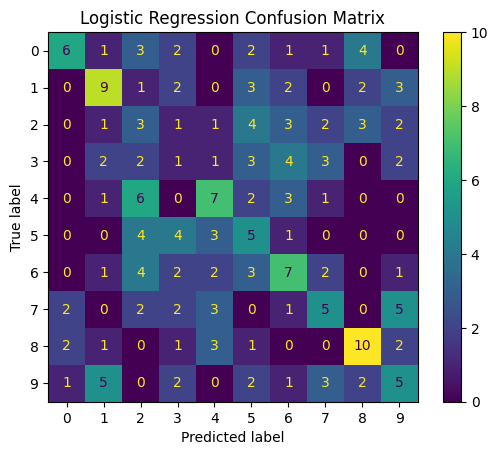

<Figure size 640x480 with 0 Axes>

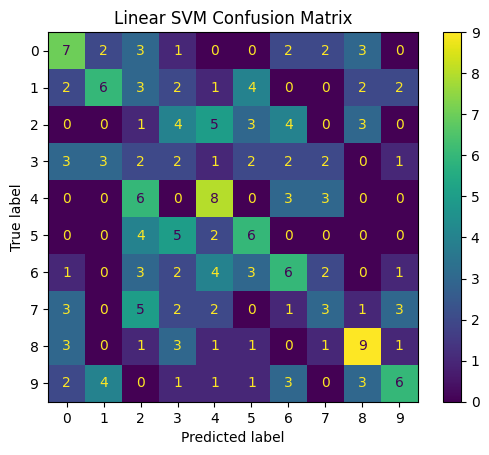

<Figure size 640x480 with 0 Axes>

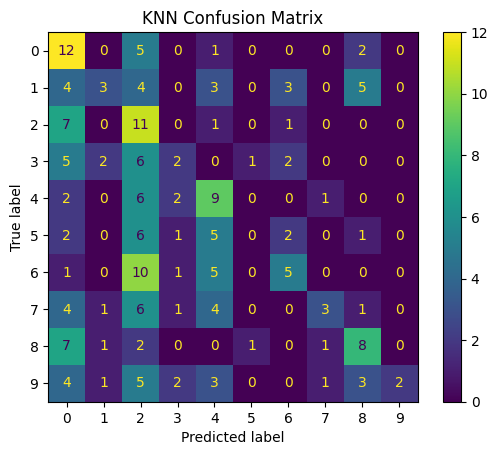

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# -----------------------------
# Validation accuracy
# -----------------------------
print("Validation Accuracy")
print("Logistic Regression:", log_acc)
print("Linear SVM:", svm_acc)
print("KNN:", knn_acc)

# -----------------------------
# Confusion Matrices
# -----------------------------
models = {
    "Logistic Regression": log_reg,
    "Linear SVM": svm_model,
    "KNN": knn_model
}

for name, model in models.items():
    y_pred = model.predict(X_val)

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm)

    plt.figure()
    disp.plot()
    plt.title(name + " Confusion Matrix")
    plt.show()

Based on the validation results, Logistic Regression achieved the highest accuracy (0.29),
compared to SVM (0.27) and KNN (0.275). Therefore, Logistic Regression is selected as the final model.

In [ ]:
from sklearn.metrics import accuracy_score

# normalize test data as we did before
X_test_small = X_test[:1000] / 255.0
y_test_small = y_test[:1000]

# prediction
test_pred = log_reg.predict(X_test_small)

# accuracy
test_acc = accuracy_score(y_test_small, test_pred)

print("Final Test Accuracy:", test_acc)

4 PyTorch task: Neural Network Classification


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as dset
import torchvision.transforms as T

import numpy as np

USE_GPU = True
dtype = torch.float32 # We will be using float throughout this assignment.

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print train loss.
print_every = 100
print('using device:', device)

using device: cuda


 CIFAR-10

In [31]:
NUM_TRAIN = 49000

# The torchvision.transforms package provides tools for preprocessing data.
# Here we set up a transform that normalizes the data by subtracting the mean
# RGB value and dividing by the standard deviation of each RGB channel.
# The mean and standard deviation values are hardcoded.
transform = T.Compose([
                T.ToTensor(),
                T.Normalize((0.4914, 0.4822, 0.4465),
                            (0.2023, 0.1994, 0.2010))
            ])

# We set up a Dataset object for each split (train / val / test).
# Datasets load examples one at a time, so we wrap each Dataset in a DataLoader
# which forms minibatches. The training set is split into train and validation
# subsets using a Sampler.
cifar10_train = dset.CIFAR10('./intro_to_ai/datasets', train=True, download=True,
                             transform=transform)
loader_train = DataLoader(cifar10_train, batch_size=64,
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))

cifar10_val = dset.CIFAR10('./intro_to_ai/datasets', train=True, download=True,
                           transform=transform)
loader_val = DataLoader(cifar10_val, batch_size=64,
                        sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, 50000)))

cifar10_test = dset.CIFAR10('./intro_to_ai/datasets', train=False, download=True,
                            transform=transform)
loader_test = DataLoader(cifar10_test, batch_size=64)

100%|██████████| 170M/170M [00:05<00:00, 30.7MB/s]


flatten and two_layer_fc

In [32]:
def flatten(x):
    N = x.shape[0] # read in N, C, H, W
    return x.view(N, -1)  # "flatten" the C * H * W values into a single vector per image

def test_flatten():
    x = torch.arange(12).view(2, 1, 3, 2)
    print('Before flattening: ', x)
    print('After flattening: ', flatten(x))

test_flatten()
import torch.nn.functional as F  # useful stateless functions

def two_layer_fc(x, params):
    """
    A fully-connected neural network; the architecture is:
    NN is fully connected -> ReLU -> fully connected layer.
    Note that this function only defines the forward pass;
    PyTorch will take care of the backward pass for us.

    The input to the network will be a minibatch of data, of shape
    (N, d1, ..., dM) where d1 * ... * dM = D. The hidden layer will have H units,
    and the output layer will produce scores for C classes.

    Inputs:
    - x: A PyTorch Tensor of shape (N, d1, ..., dM) giving a minibatch of
      input data.
    - params: A list [w1, w2] of PyTorch Tensors giving weights for the network;
      w1 has shape (D, H) and w2 has shape (H, C).

    Returns:
    - scores: A PyTorch Tensor of shape (N, C) giving classification scores for
      the input data x.
    """
    # first we flatten the image
    x = flatten(x)  # shape: [batch_size, C x H x W]

    w1, w2 = params

    # Forward pass: compute predicted y using operations on Tensors. Since w1 and
    # w2 have requires_grad=True, operations involving these Tensors will cause
    # PyTorch to build a computational graph, allowing automatic computation of
    # gradients. Since we are no longer implementing the backward pass by hand we
    # don't need to keep references to intermediate values.
    # you can also use `.clamp(min=0)`, equivalent to F.relu()
    x = F.relu(x.mm(w1))
    x = x.mm(w2)
    return x


def two_layer_fc_test():
    hidden_layer_size = 42
    x = torch.zeros((64, 50), dtype=dtype)  # minibatch size 64, feature dimension 50
    w1 = torch.zeros((50, hidden_layer_size), dtype=dtype)
    w2 = torch.zeros((hidden_layer_size, 10), dtype=dtype)
    scores = two_layer_fc(x, [w1, w2])
    print(scores.size())  # you should see [64, 10]

two_layer_fc_test()

Before flattening:  tensor([[[[ 0,  1],
          [ 2,  3],
          [ 4,  5]]],


        [[[ 6,  7],
          [ 8,  9],
          [10, 11]]]])
After flattening:  tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])
torch.Size([64, 10])


weights


In [33]:
def random_weight(shape):
    """
    Create random Tensors for weights; setting requires_grad=True means that we
    want to compute gradients for these Tensors during the backward pass.
    We use Kaiming normalization: sqrt(2 / fan_in)
    """
    if len(shape) == 2:  # FC weight
        fan_in = shape[0]
    else:
        fan_in = np.prod(shape[1:]) # general fan-in computation
    # randn is standard normal distribution generator.
    w = torch.randn(shape, device=device, dtype=dtype) * np.sqrt(2. / fan_in)
    w.requires_grad = True
    return w

def zero_weight(shape):
    return torch.zeros(shape, device=device, dtype=dtype, requires_grad=True)

# create a weight of shape [3 x 5]
# you should see the type `torch.cuda.FloatTensor` if you use GPU.
# Otherwise it should be `torch.FloatTensor`
random_weight((3, 5))

tensor([[ 0.8136,  0.1599, -0.4464,  0.1769,  0.0574],
        [-1.2011, -0.1094, -0.4039,  0.0599,  0.5309],
        [ 0.1152,  0.0015, -0.0195,  0.7192, -0.2511]], device='cuda:0',
       requires_grad=True)

 check_accuracy_part2

In [34]:
def check_accuracy_part2(loader, model_fn, params):
    """
    Check the accuracy of a classification model.

    Inputs:
    - loader: A DataLoader for the data split we want to check
    - model_fn: A function that performs the forward pass of the model,
      with the signature scores = model_fn(x, params)
    - params: List of PyTorch Tensors giving parameters of the model

    Returns: Nothing, but prints the accuracy of the model
    """
    split = 'val' if loader.dataset.train else 'test'
    print('Checking accuracy on the %s set' % split)
    num_correct, num_samples = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.int64)
            scores = model_fn(x, params)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f%%)' % (num_correct, num_samples, 100 * acc))

In [35]:
def train_part2(model_fn, params, learning_rate):

    for t, (x, y) in enumerate(loader_train):

        x = x.to(device=device, dtype=dtype)
        y = y.to(device=device, dtype=torch.long)

        scores = model_fn(x, params)
        loss = F.cross_entropy(scores, y)

        loss.backward()

        with torch.no_grad():
            for w in params:
                w -= learning_rate * w.grad
                w.grad.zero_()

        if t % print_every == 0:
            print('Iteration %d, loss = %.4f' % (t, loss.item()))
            check_accuracy_part2(loader_val, model_fn, params)
            print()

In [36]:
hidden_layer_size = 4000
learning_rate = 1e-2

w1 = random_weight((3 * 32 * 32, hidden_layer_size))
w2 = random_weight((hidden_layer_size, 10))

train_part2(two_layer_fc, [w1, w2], learning_rate)

Iteration 0, loss = 3.7708
Checking accuracy on the val set
Got 164 / 1000 correct (16.40%)

Iteration 100, loss = 2.4830
Checking accuracy on the val set
Got 337 / 1000 correct (33.70%)

Iteration 200, loss = 2.0284
Checking accuracy on the val set
Got 425 / 1000 correct (42.50%)

Iteration 300, loss = 1.7505
Checking accuracy on the val set
Got 382 / 1000 correct (38.20%)

Iteration 400, loss = 2.1113
Checking accuracy on the val set
Got 405 / 1000 correct (40.50%)

Iteration 500, loss = 1.7900
Checking accuracy on the val set
Got 418 / 1000 correct (41.80%)

Iteration 600, loss = 1.5960
Checking accuracy on the val set
Got 427 / 1000 correct (42.70%)

Iteration 700, loss = 1.5548
Checking accuracy on the val set
Got 456 / 1000 correct (45.60%)



TwoLayerFC

In [37]:
class TwoLayerFC(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        # assign layer objects to class attributes
        self.fc1 = nn.Linear(input_size, hidden_size)
        nn.init.kaiming_normal_(self.fc1.weight)

        self.fc2 = nn.Linear(hidden_size, num_classes)
        nn.init.kaiming_normal_(self.fc2.weight)

    def forward(self, x):
        x = flatten(x)
        scores = self.fc2(F.relu(self.fc1(x)))
        return scores


def test_TwoLayerFC():
    input_size = 50
    x = torch.zeros((64, input_size), dtype=dtype)

    model = TwoLayerFC(input_size, 42, 10)
    scores = model(x)

    print(scores.size())

test_TwoLayerFC()

torch.Size([64, 10])


 check_accuracy_parts 3 and 4

In [38]:
def check_accuracy_part34(loader, model):

    if loader.dataset.train:
        print('Checking accuracy on validation set')
    else:
        print('Checking accuracy on test set')

    num_correct = 0
    num_samples = 0

    model.eval()

    with torch.no_grad():
        for x, y in loader:

            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)

            _, preds = scores.max(1)

            num_correct += (preds == y).sum()
            num_samples += preds.size(0)

        acc = float(num_correct) / num_samples

        print('Got %d / %d correct (%.2f)' % (num_correct, num_samples, 100 * acc))

train_parts 3 4

In [39]:
def train_part34(model, optimizer, epochs=1):

    model = model.to(device=device)

    for e in range(epochs):

        for t, (x, y) in enumerate(loader_train):

            model.train()

            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)

            loss = F.cross_entropy(scores, y)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            if t % print_every == 0:

                print('Iteration %d, loss = %.4f' % (t, loss.item()))

                check_accuracy_part34(loader_val, model)

                print()

4.1 What you must implement

In [40]:
################################################################################
# TODO:                                                                        #
# Experiment with any architectures, optimizers, and hyperparameters.          #
# Achieve high accuracy on the *validation set* within 10 epochs.              #
#                                                                              #
# Note that you can use the check_accuracy function to evaluate on either      #
# the test set or the validation set, by passing either loader_test or         #
# loader_val as the second argument to check_accuracy. You should not touch    #
# the test set until you have finished your architecture and  hyperparameter   #
# tuning, and only run the test set once at the end to report a final value.   #
################################################################################
################################################################################

class CIFAR10Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CIFAR10Net()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


################################################################################
#                                 END OF YOUR CODE                             #
################################################################################

train_part34(model, optimizer, epochs=10)

Iteration 0, loss = 2.3746
Checking accuracy on validation set
Got 93 / 1000 correct (9.30)

Iteration 100, loss = 1.5884
Checking accuracy on validation set
Got 349 / 1000 correct (34.90)

Iteration 200, loss = 1.6060
Checking accuracy on validation set
Got 374 / 1000 correct (37.40)

Iteration 300, loss = 1.6935
Checking accuracy on validation set
Got 480 / 1000 correct (48.00)

Iteration 400, loss = 1.5238
Checking accuracy on validation set
Got 450 / 1000 correct (45.00)

Iteration 500, loss = 1.5021
Checking accuracy on validation set
Got 515 / 1000 correct (51.50)

Iteration 600, loss = 1.5488
Checking accuracy on validation set
Got 530 / 1000 correct (53.00)

Iteration 700, loss = 1.3672
Checking accuracy on validation set
Got 563 / 1000 correct (56.30)

Iteration 0, loss = 1.1488
Checking accuracy on validation set
Got 598 / 1000 correct (59.80)

Iteration 100, loss = 1.3289
Checking accuracy on validation set
Got 567 / 1000 correct (56.70)

Iteration 200, loss = 1.1279
Checkin

4.2 hyperparameter search

In [41]:
learning_rates = [1e-2, 1e-3, 1e-4]

for lr in learning_rates:

    print("Training with learning rate:", lr)

    model = CIFAR10Net()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    train_part34(model, optimizer, epochs=2)

    print("Validation result:")
    check_accuracy_part34(loader_val, model)

    print("--------------")

Training with learning rate: 0.01
Iteration 0, loss = 2.4151
Checking accuracy on validation set
Got 120 / 1000 correct (12.00)

Iteration 100, loss = 2.3026
Checking accuracy on validation set
Got 86 / 1000 correct (8.60)

Iteration 200, loss = 2.2237
Checking accuracy on validation set
Got 112 / 1000 correct (11.20)

Iteration 300, loss = 2.3114
Checking accuracy on validation set
Got 157 / 1000 correct (15.70)

Iteration 400, loss = 2.1381
Checking accuracy on validation set
Got 201 / 1000 correct (20.10)

Iteration 500, loss = 2.0421
Checking accuracy on validation set
Got 237 / 1000 correct (23.70)

Iteration 600, loss = 2.0053
Checking accuracy on validation set
Got 247 / 1000 correct (24.70)

Iteration 700, loss = 2.1644
Checking accuracy on validation set
Got 243 / 1000 correct (24.30)

Iteration 0, loss = 1.8072
Checking accuracy on validation set
Got 266 / 1000 correct (26.60)

Iteration 100, loss = 2.0905
Checking accuracy on validation set
Got 281 / 1000 correct (28.10)

It

Sections 4.2 and 4.3 are included and described in the Overleaf report.